In [2]:
import random

def generate_synthetic_sequences(n_samples=1000, seq_length=10):
    """
    Generate synthetic DNA sequences with labels.
    
    Coding (label=1): High GC content (>60%)
    Non-coding (label=0): Low GC content (<40%)
    
    Returns:
        sequences: List of DNA strings
        labels: List of labels (0 or 1)
    """
    sequences = []
    labels = []
    
    for i in range(n_samples):
        if i < n_samples // 2:
            # Generate coding sequence (high GC)
            seq = generate_high_gc_sequence(seq_length)
            label = 1
        else:
            # Generate non-coding sequence (low GC)
            seq = generate_low_gc_sequence(seq_length)
            label = 0
        
        sequences.append(seq)
        labels.append(label)
    
    return sequences, labels

def generate_high_gc_sequence(seq_length):
    """Generate sequence with >60% GC content"""
    seq = []    
    gc_count = 0
    for i in range(seq_length):
        if gc_count < seq_length * 0.6:
            # Choose G or C
            base = random.choice(['G', 'C'])
            gc_count += 1
        else:
            # Choose A or T
            base = random.choice(['A', 'T'])
        seq.append(base)
    return ''.join(seq)

def generate_low_gc_sequence(seq_length):
    """Generate sequence with <40% GC content"""
    seq = []
    gc_count = 10
    for i in range(seq_length):
        if gc_count > seq_length * 0.4:
            # Choose A or T
            base = random.choice(['A', 'T'])
            gc_count -= 1
        else:
            # Choose G or C
            base = random.choice(['G', 'C'])
        seq.append(base)
    return ''.join(seq)

# Check GC content
def calculate_gc_content(seq):
    gc_count = seq.count('G') + seq.count('C')
    return gc_count / len(seq)

In [3]:
sequences, labels = generate_synthetic_sequences(1000, 10)

print("\nFirst 5 sequences:")
for i in range(5):
    gc = calculate_gc_content(sequences[i])
    print(f"  {sequences[i]} → label={labels[i]} (GC={gc:.1%})")


First 5 sequences:
  CGCCGCAAAA → label=1 (GC=60.0%)
  GCCGCGTATT → label=1 (GC=60.0%)
  GGGCGCTATT → label=1 (GC=60.0%)
  GGCCCGTAAA → label=1 (GC=60.0%)
  CCGCGCATTA → label=1 (GC=60.0%)


In [4]:
#Import sequence one-hot encoder and encode sequences

import sys
import torch

sys.path.append('../src/')

from SequenceEncoder import SequenceEncoder

encoder = SequenceEncoder()

encoded_sequences = []

for seq in sequences:
    encoded_seq = encoder.encode(seq)
    flattened_seq = encoded_seq.flatten()
    encoded_sequences.append(flattened_seq)

X = torch.stack(encoded_sequences)
print(f"\nEncoded sequences shape: {X.shape}")


Encoded sequences shape: torch.Size([1000, 40])


In [5]:
y = torch.tensor(labels, dtype=torch.float32).unsqueeze(-1)

print(f"Labels shape: {y.shape}")

Labels shape: torch.Size([1000, 1])


In [6]:
from sklearn.model_selection import train_test_split

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {len(X_train)}")  
print(f"Test samples: {len(X_test)}")

print(f"\nX_train shape: {X_train.shape}")  # (800, 40)
print(f"X_test shape: {X_test.shape}")      # (200, 40)
print(f"y_train shape: {y_train.shape}")    # (800, 1)
print(f"y_test shape: {y_test.shape}")      # (200, 1)

# Verify class balance
train_coding = y_train.sum().item()
train_noncoding = len(y_train) - train_coding
test_coding = y_test.sum().item()
test_noncoding = len(y_test) - test_coding

print(f"\nTrain: {train_coding:.0f} coding, {train_noncoding:.0f} non-coding")
print(f"Test: {test_coding:.0f} coding, {test_noncoding:.0f} non-coding")


Training samples: 800
Test samples: 200

X_train shape: torch.Size([800, 40])
X_test shape: torch.Size([200, 40])
y_train shape: torch.Size([800, 1])
y_test shape: torch.Size([200, 1])

Train: 400 coding, 400 non-coding
Test: 100 coding, 100 non-coding


In [7]:
# Part 3: Training Components
import torch.nn as nn
import torch.optim as optim
from models import SimpleDNAClassifier

# Create model
model = SimpleDNAClassifier(input_size=40, hidden_size=64, output_size=1)
print(model)

# Loss function
criterion = nn.BCELoss()

# Optimizer  
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\n✅ Ready to train!")

SimpleDNAClassifier(
  (fc1): Linear(in_features=40, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (pred): Sigmoid()
)

✅ Ready to train!


In [ ]:
# Training configuration
num_epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

print("Starting training...\n")

for epoch in range(num_epochs):
    # ========== TRAINING MODE ==========
    model.train()  # Set model to training mode
    
    # Forward pass
    train_predictions = model(X_train)
    train_loss = criterion(train_predictions, y_train)
    
    # Backward pass
    optimizer.zero_grad()  # Clear old gradients
    train_loss.backward()  # Calculate new gradients
    optimizer.step()       # Update parameters (weight -= lr * grad)
    
    # Calculate training accuracy
    train_pred_labels = (train_predictions > 0.5).float()
    train_acc = (train_pred_labels == y_train).float().mean().item()
    
    # ========== EVALUATION MODE ==========
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # Don't calculate gradients for evaluation
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        
        # Calculate test accuracy
        test_pred_labels = (test_predictions > 0.5).float()
        test_acc = (test_pred_labels == y_test).float().mean().item()
    
    # Track metrics
    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss.item():.4f}, Train Acc: {train_acc:.2%}")
        print(f"  Test Loss: {test_loss.item():.4f}, Test Acc: {test_acc:.2%}")
        print()

print("✅ Training complete!")
print(f"\nFinal Results:")
print(f"  Train Accuracy: {train_accuracies[-1]:.2%}")
print(f"  Test Accuracy: {test_accuracies[-1]:.2%}")

In [9]:
# Create some test sequences
test_sequences = [
    "GCGCGCGCGC",  # Very high GC → should predict coding (1)
    "ATATATATAT",  # Very low GC → should predict non-coding (0)
    "GCGATCGCGA",  # High GC → should predict coding (1)
    "ATATGCATAT",  # Medium-low GC → should predict non-coding (0)
]

print("Testing model on new sequences:\n")

model.eval()
with torch.no_grad():
    for seq in test_sequences:
        # Encode the sequence
        encoded = encoder.encode(seq).flatten().unsqueeze(0)  # (1, 40)
        
        # Get prediction
        prob = model(encoded).item()
        prediction = 1 if prob > 0.5 else 0
        
        # Calculate actual GC content
        gc_content = (seq.count('G') + seq.count('C')) / len(seq)
        
        # Display results
        print(f"Sequence: {seq}")
        print(f"  GC content: {gc_content:.1%}")
        print(f"  Predicted probability: {prob:.4f}")
        print(f"  Predicted class: {prediction} ({'Coding' if prediction == 1 else 'Non-coding'})")
        print(f"  Confidence: {'High' if abs(prob - 0.5) > 0.4 else 'Medium'}")
        print()

Testing model on new sequences:

Sequence: GCGCGCGCGC
  GC content: 100.0%
  Predicted probability: 0.7610
  Predicted class: 1 (Coding)
  Confidence: Medium

Sequence: ATATATATAT
  GC content: 0.0%
  Predicted probability: 0.2686
  Predicted class: 0 (Non-coding)
  Confidence: Medium

Sequence: GCGATCGCGA
  GC content: 70.0%
  Predicted probability: 0.4544
  Predicted class: 0 (Non-coding)
  Confidence: Medium

Sequence: ATATGCATAT
  GC content: 20.0%
  Predicted probability: 0.6841
  Predicted class: 1 (Coding)
  Confidence: Medium



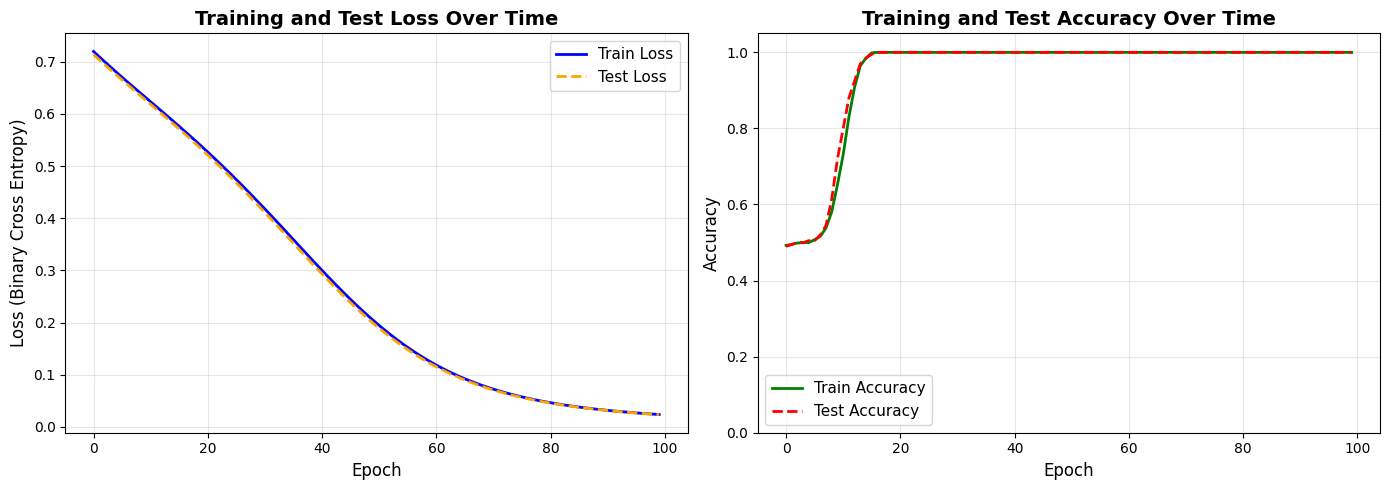

✅ Training curves saved as 'training_curves.png'


In [10]:
import matplotlib.pyplot as plt

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(train_losses, label='Train Loss', linewidth=2, color='blue')
axes[0].plot(test_losses, label='Test Loss', linewidth=2, linestyle='--', color='orange')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (Binary Cross Entropy)', fontsize=12)
axes[0].set_title('Training and Test Loss Over Time', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy curves  
axes[1].plot(train_accuracies, label='Train Accuracy', linewidth=2, color='green')
axes[1].plot(test_accuracies, label='Test Accuracy', linewidth=2, linestyle='--', color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Test Accuracy Over Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training curves saved as 'training_curves.png'")

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions on test set
model.eval()
with torch.no_grad():
    test_predictions = model(X_test)
    test_pred_labels = (test_predictions > 0.5).float()

# Convert to numpy for sklearn
y_test_np = y_test.cpu().numpy().flatten()
y_pred_np = test_pred_labels.cpu().numpy().flatten()

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred_np)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-coding', 'Coding'],
            yticklabels=['Non-coding', 'Coding'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print("="*50)
report = classification_report(y_test_np, y_pred_np, 
                               target_names=['Non-coding', 'Coding'],
                               digits=4)
print(report)

# Manual calculation to understand metrics
tn, fp, fn, tp = cm.ravel()
print("\n📈 Detailed Metrics:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print(f"\nPrecision: {tp/(tp+fp):.4f} (of predicted coding, how many were actually coding)")
print(f"Recall: {tp/(tp+fn):.4f} (of actual coding, how many did we find)")
print(f"F1-Score: {2*tp/(2*tp+fp+fn):.4f} (harmonic mean of precision and recall)")

In [16]:
import os

# Create models directory
os.makedirs('saved_models', exist_ok=True)

# Save model state
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_losses[-1],
    'test_loss': test_losses[-1],
    'train_accuracy': train_accuracies[-1],
    'test_accuracy': test_accuracies[-1],
    'epoch': num_epochs,
    'model_config': {
        'input_size': 40,
        'hidden_size': 64,
        'output_size': 1
    }
}, 'saved_models/dna_classifier.pth')

print("✅ Model saved to 'saved_models/dna_classifier.pth'")

✅ Model saved to 'saved_models/dna_classifier.pth'


In [17]:
from models import SimpleDNAClassifier

# Create new model instance
loaded_model = SimpleDNAClassifier(input_size=40, hidden_size=64, output_size=1)

# Load saved weights
checkpoint = torch.load('saved_models/dna_classifier.pth')
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print("✅ Model loaded successfully!")
print(f"   Training accuracy: {checkpoint['train_accuracy']:.2%}")
print(f"   Test accuracy: {checkpoint['test_accuracy']:.2%}")

# Test that it works
test_seq = "GCGCGCGCGC"
with torch.no_grad():
    encoded = encoder.encode(test_seq).flatten().unsqueeze(0)
    prob = loaded_model(encoded).item()
    print(f"\nTest prediction on '{test_seq}': {prob:.4f} ({'Coding' if prob > 0.5 else 'Non-coding'})")

✅ Model loaded successfully!
   Training accuracy: 100.00%
   Test accuracy: 100.00%

Test prediction on 'GCGCGCGCGC': 0.7610 (Coding)
